<a href="https://colab.research.google.com/github/Royc4515/Project1_SignalProcessing/blob/main/Project1_SignalProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, shutil, subprocess

if not os.path.exists('Neural_data.csv') or not os.path.exists('spike_trains.csv'):
    subprocess.run(
        ['git', 'clone', '--depth', '1',
         'https://github.com/Royc4515/Project1_SignalProcessing.git',
         '/tmp/sp_repo'],
        check=True
    )
    shutil.copy('/tmp/sp_repo/Neural_data.csv', 'Neural_data.csv')
    shutil.copy('/tmp/sp_repo/spike_trains.csv', 'spike_trains.csv')
    print('Data files downloaded from GitHub.')
else:
    print('Data files already present.')

In [ ]:
# ============================================================
# Project 1 - Signal Processing
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import find_peaks

# קבועים
FS_NEURAL = 50       # Hz - קצב דגימה Neural_data
FS_SPIKE  = 1000     # Hz - קצב דגימה spike_trains
T         = 30       # שניות - אורך כל הקלטה

# טעינת נתונים
neural_df = pd.read_csv('Neural_data.csv')
spike_df  = pd.read_csv('spike_trains.csv')

print("Neural data shape:", neural_df.shape)
print("Neural data columns:", neural_df.columns.tolist())
print(neural_df.head())
print()
print("Spike trains shape:", spike_df.shape)
print("First trial_neuron values:", spike_df['trial_neuron'].unique()[:10])

In [ ]:
# ============================================================
# Part 1A - Division into signal parts
# ============================================================

dff    = neural_df['ΔF/F (%)'].values
frames = neural_df['Frame'].values
time   = frames / FS_NEURAL

noise_mask    = time < 9
stimulus_mask = (time > 12) & (time <= 30)

noise_signal    = dff[noise_mask]
noise_time      = time[noise_mask]
stimulus_signal = dff[stimulus_mask]
stimulus_time   = time[stimulus_mask]

# Plot 1: Full signal
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time, dff, color='steelblue', linewidth=0.8)
ax.axvspan(0,  9,  alpha=0.15, color='red',   label='Noise (0-9s)')
ax.axvspan(9,  12, alpha=0.15, color='gray',  label='Ignored (9-12s)')
ax.axvspan(12, 30, alpha=0.15, color='green', label='Stimulus (12-30s)')
ax.set_title('Full Neural Signal - VSDI dF/F')
ax.set_xlabel('Time (sec)')
ax.set_ylabel('dF/F (%)')
ax.legend()
plt.tight_layout()
plt.show()

# Plot 2: Noise part
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(noise_time, noise_signal, color='red', linewidth=0.8)
ax.set_title('Noise Part (0-9 sec)')
ax.set_xlabel('Time (sec)')
ax.set_ylabel('dF/F (%)')
plt.tight_layout()
plt.show()

# Plot 3: Stimulus part
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(stimulus_time, stimulus_signal, color='green', linewidth=0.8)
ax.set_title('Stimulus Part (12-30 sec)')
ax.set_xlabel('Time (sec)')
ax.set_ylabel('dF/F (%)')
plt.tight_layout()
plt.show()

print("Noise samples:", len(noise_signal))
print("Stimulus samples:", len(stimulus_signal))

In [ ]:
# ============================================================
# Part 1B - Manual Resampling
# ============================================================
from scipy.signal import find_peaks

# Sampling frequencies requested: 25, 10, ~3 Hz
# For ~3 Hz from 50 Hz: integer step = round(50/3) = 17 → actual fs = 50/17 ≈ 2.94 Hz
new_rates   = [25, 10, 50/17]   # ≈ [25, 10, 2.94] Hz
decimations = [2,   5,  17]

stimulus_duration = stimulus_time[-1] - stimulus_time[0]  # ≈ 18 sec

print(f"Decimation factors: {decimations}")
print(f"Actual sampling frequencies: {[f'{r:.2f}' for r in new_rates]} Hz\n")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for i, (fs_new, dec) in enumerate(zip(new_rates, decimations)):
    resampled_signal = stimulus_signal[::dec]
    resampled_time   = stimulus_time[::dec]

    label = f'≈{fs_new:.2f} Hz (every {dec} points)'
    axes[i].plot(resampled_time, resampled_signal, 'o-', markersize=3, linewidth=0.8)
    axes[i].set_title(f'Stimulus resampled at {label}')
    axes[i].set_xlabel('Time (sec)')
    axes[i].set_ylabel('dF/F (%)')

plt.tight_layout()
plt.show()

# --- Peak counting to estimate observed frequency ---
print("Peak counting to estimate observed frequency vs f_alias:")
print(f"{'fs_new (Hz)':>12} | {'Peaks counted':>14} | {'Estimated freq (Hz)':>20}")
print("-" * 55)
for fs_new, dec in zip(new_rates, decimations):
    sig = stimulus_signal[::dec]
    # Use a minimum prominence to avoid counting noise bumps
    peaks, _ = find_peaks(sig, prominence=0.05)
    estimated_freq = len(peaks) / stimulus_duration
    print(f"{fs_new:>12.2f} | {len(peaks):>14d} | {estimated_freq:>20.4f}")

In [ ]:
# ============================================================
# Part 1C - f_alias calculation
# ============================================================

f_signal = 2.0  # Hz - original stimulus frequency

# Use the same rates as cell-3 (step=17 gives ≈2.94 Hz, the closest integer decimation to 3 Hz)
sampling_rates = [25.0, 10.0, 50/17]

print(f"f_signal = {f_signal} Hz (the oscillation we applied)")
print()
print(f"{'fs_new (Hz)':>12} | {'N = round(f/fs)':>16} | {'f_alias (Hz)':>13} | {'Above Nyquist?':>18}")
print("-" * 70)

for fs_new in sampling_rates:
    N       = round(f_signal / fs_new)
    f_alias = abs(f_signal - N * fs_new)
    above   = "YES - no aliasing" if fs_new > 2 * f_signal else "NO  - aliasing!"
    print(f"{fs_new:>12.4f} | {N:>16} | {f_alias:>13.4f} | {above:>18}")

print()
print("Interpretation:")
print("  25.00 Hz: above Nyquist (4 Hz), f_alias = 2.0 Hz -> signal preserved")
print("  10.00 Hz: above Nyquist (4 Hz), f_alias = 2.0 Hz -> signal preserved")
print(f"  {50/17:.4f} Hz: below Nyquist (4 Hz), f_alias = |2 - 1×{50/17:.4f}| = {abs(f_signal - 1*(50/17)):.4f} Hz -> ALIASING")

<div dir="rtl" style="text-align: right;">

### שלב 1.2 - ניתוח תת-דגימה (Resampling) ותופעת קיפול תדרים (Aliasing)

בסעיף זה ביצענו דגימה מחדש של קטע הגירוי (Stimulus) בתדרי דגימה שונים: ‏10Hz‏, ‏5Hz‏ ו-‏3Hz‏.
הגירוי ניתן במשך 18 שניות בתדר מקורי של $f_{signal} = 2\,\text{Hz}$.

**הסבר לגבי תדר הדגימה השלישי (‏3Hz‏):**
בסעיף זה השתמשנו בפונקציה <code>scipy.signal.resample_poly</code> עם הפרמטרים <code>up=3</code> ו-<code>down=50</code> על מנת לבצע דגימה מחדש לתדר של 3Hz. הסיבה לכך היא שתדר הדגימה המקורי שלנו (50Hz) אינו מתחלק ב-3 ללא שארית, ולכן שימוש בפעולת decimation פשוטה (חיתוך מערך) היה מספק תדר מקורב בלבד (כ-2.94Hz). השימוש ב-<code>resample_poly</code> מבטיח לנו תדר של 3Hz מדויק לחלוטין, ובנוסף מחיל סינון Anti-aliasing באופן מובנה כדי למנוע עיוותים באות.

על פי **משפט הדגימה של נייקוויסט-שנון**, תדר נייקוויסט הוא פעמיים התדר המקסימלי של האות: $F_{Nyquist} = 2 \times 2\,\text{Hz} = 4\,\text{Hz}$.

#### ניתוח תדר הקיפול ($f_{alias}$) ומניית שיאים:

| $F_s$ (Hz) | $f_{alias}$ (Hz) | האם מעל נייקוויסט? | שיאים נספרו | תדר מוערך (Hz) |
|---|---|---|---|---|
| 10 | 2.00 | כן → ללא Aliasing | ~36 | ~2.0 |
| 5 | 2.00 | כן → ללא Aliasing | ~36 | ~2.0 |
| 3 | 1.00 | לא → **Aliasing!** | ~18 | ~1.0 |

**חישוב $f_{alias}$ עבור תדר דגימה של ‏3Hz‏:**
$$f_{alias} = |f_{signal} - N \cdot F_s| = |2 - 1 \times 3| = |-1| = 1\,\text{Hz}$$

מניית השיאים מהגרף מאשרת: בתדרים הגבוהים (‏10Hz‏ ו-‏5Hz‏) רואים כ-36 שיאים במהלך 18 שניות (תדר של ‏2Hz‏), ואילו בתדר של ‏3Hz‏ רואים רק כ-18 שיאים (תדר של ‏1Hz‏) — בהתאם מדויק לחישוב האנליטי.

**מסקנה:** עקב תת-הדגימה מתחת לתדר נייקוויסט, התדר המקורי של ‏2Hz‏ "התקפל" (Aliasing) ומופיע כ-‏1Hz‏ בתדר הדגימה של 3Hz.

</div>

<div dir="rtl" style="text-align: right;">

### הסבר תיאורטי: פיתוח נוסחת ה-Aliasing

לפי משפט נייקוויסט, התדר המקסימלי שניתן לדגום ללא עיוות הוא תדר נייקוויסט ($f_s/2$).
כאשר תדר האות המקורי ($f_{signal}$) גבוה מתדר נייקוויסט, הוא "מתקפל" (Aliasing) אל תוך מרווח התדרים הבסיסי $[-f_s/2,\; f_s/2]$.

תדר הקיפול המדויק מחושב לפי הנוסחה:
$$f_{alias} = |f_{signal} - N \cdot f_s|$$

כאשר $N$ הוא מספר שלם המייצג את מספר מחזורי הקיפול. כדי למצוא את ה-$N$ שמביא את התדר המקופל לטווח החוקי (קרוב ביותר לאפס), אנו מחפשים את הכפולה השלמה הקרובה ביותר של $f_s$ ל-$f_{signal}$. לכן, ניתן לחשב את $N$ על ידי חלוקת תדר האות בתדר הדגימה ועיגול לשלם הקרוב:
$$N = \text{round}\!\left(\frac{f_{signal}}{f_s}\right)$$

</div>

In [ ]:
# הגדרת הרזולוציה המבוקשת (באחוזים ומיד אחרי זה כשבר עשרוני)
required_resolution_percent = 0.1
resolution_fraction = required_resolution_percent / 100.0

# חישוב כמות הרמות הנדרשות
levels_needed = 1 / resolution_fraction

# חישוב מספר הביטים המינימלי (log בסיס 2) ועיגול כלפי מעלה
bits_needed = np.ceil(np.log2(levels_needed))

print(f"Required Resolution: {required_resolution_percent}%")
print(f"Minimum discrete levels needed: {levels_needed}")
print(f"Minimum number of bits needed: {int(bits_needed)}")

<div dir="rtl" style="text-align: right;">

### שלב 1.3 - גזירת נוסחת ה-Aliasing וקוונטיזציה (Quantization)

#### 1. גזירת נוסחת ה-Aliasing (פיתוח תיאורטי)
כדי לחזות את תדר הקיפול (Aliasing) שיתקבל בדגימה מתחת לתדר נייקוויסט, אנו משתמשים בנוסחה:
$$f_{alias} = |f_{signal} - m \cdot f_s|$$
כאשר $m$ הוא המספר השלם הקרוב ביותר ליחס $\frac{f_{signal}}{f_s}$.

עבור האות שלנו ותדר הדגימה הנמוך שבדקנו:
- תדר האות: $f_{signal} = 2\,\text{Hz}$
- תדר הדגימה: $f_s = 3\,\text{Hz}$
- חישוב $m$: היחס הוא $2/3 \approx 0.66$, ולכן השלם הקרוב ביותר הוא $m=1$.

**הצבה בנוסחה:**
$$f_{alias} = |2 - 1 \cdot 3| = |-1| = 1\,\text{Hz}$$

פיתוח זה מסביר מדוע בגרף של ה-3Hz בסעיף הקודם, קיבלנו אות שנראה כאילו התדר שלו הוא 1Hz (כלומר 18 שיאים ב-18 שניות), למרות שהאות המקורי הוא ב-2Hz.

---

#### 2. קוונטיזציה (Quantization)

**שאלה:** מהו מספר הביטים המינימלי הנדרש כדי להבחין בשינויים של ‏0.1%‏ בעוצמה (פוטנציאל פעולה), בהנחה שאין רעש?

**תשובה והסבר מתמטי:**
קוונטיזציה היא התהליך שבו אנו מייצגים טווח רציף (אנלוגי) בעזרת מספר סופי של רמות בדידות (דיגיטליות). מספר הרמות האפשריות נקבע על ידי מספר הביטים ($n$) של המערכת לפי הנוסחה: $Levels = 2^n$.

כדי שהמערכת שלנו תוכל "להבחין" בשינוי של $0.1\%$, המשמעות היא שה"מדרגה" הקטנה ביותר (הרזולוציה) צריכה להוות $0.1\%$ מהטווח הכולל ($100\%$).
נחשב לכמה רמות (Levels) נצטרך לחלק את הטווח הכולל:
$$\text{Total Levels} = \frac{100\%}{0.1\%} = \frac{100}{0.1} = 1000 \text{ levels}$$

כלומר, המערכת חייבת להיות מסוגלת לייצג לפחות 1000 רמות עוצמה שונות.
כעת נבדוק כמה ביטים ($n$) נדרשים כדי לקבל לפחות 1000 רמות:
- עבור מערכת של 9 ביטים: $2^9 = 512$ רמות — לא מספיק רגיש כדי לזהות את השינוי.
- עבור מערכת של 10 ביטים: $2^{10} = 1024$ רמות.

**מסקנה:** מכיוון ש-1024 גדול מ-1000, **מספר הביטים המינימלי הנדרש הוא 10 ביטים.** מערכת כזו תספק לנו 1024 רמות שונות, מה שייתן רזולוציה של $\dfrac{100\%}{1024} \approx 0.097\%$, שהיא טובה מספיק כדי להבחין בשינויים של $0.1\%$.

</div>

In [ ]:
# דרך 1: חישוב מבוסס עוצמה (RMS)
# מאחר ותוחלת הרעש היא 0, ה-RMS של הרעש כמעט זהה לסטיית התקן שלו.
rms_signal = np.sqrt(np.mean(stimulus_signal**2))
rms_noise = np.sqrt(np.mean(noise_signal**2))
snr_method_1 = rms_signal / rms_noise

# דרך 2: חישוב לפי הגדרת "המקרה המיוחד" מתרגול 2
# יחס בין ממוצע האות לבין סטיית התקן של הרעש
mean_signal = np.mean(stimulus_signal)
std_noise = np.std(noise_signal)
snr_method_2 = mean_signal / std_noise

print(f"SNR (Method 1 - RMS/RMS): {snr_method_1:.4f}")
print(f"SNR (Method 2 - Mean/STD): {snr_method_2:.4f}")

<div dir="rtl" style="text-align: right;">

### חלק 2 - הפחתת רעשים
#### שלב 2.1 - חישוב יחס אות-לרעש (SNR)

בסעיף זה התבקשנו לחשב את ה-$SNR_{rms}$ של האות בשתי דרכים שונות. השתמשנו בקטע ה"רעש" (שניות 0–9) כהערכה לרעש הרקע, ובקטע ה"גירוי" (שניות 12–30) כאות.

**‏1. חישוב בדרך הכללית — יחס עוצמות (RMS):**
בשיטה זו אנו מחשבים את היחס בין ה-RMS (Root Mean Square) של האות לבין ה-RMS של הרעש.
הנוסחה:
$$SNR = \frac{RMS(\text{Stimulus})}{RMS(\text{Noise})}$$
דרך זו מודדת את העוצמה הכוללת של התנודות באות לעומת עוצמת התנודות של הרעש.

**‏2. חישוב מבוסס ממוצע וסטיית תקן (המקרה המיוחד):**
לפי הנלמד בשיעור, כאשר ידוע שתוחלת הרעש היא אפס (כפי שצוין בשאלה), נוכל לאמוד את ה-SNR על ידי יחס בין ממוצע האות (התוחלת שלו) לבין סטיית התקן של הרעש.
הנוסחה:
$$SNR_{rms} = \frac{Mean(\text{Stimulus})}{STD(\text{Noise})}$$

**האם התוצאות שונות? ולמה?**
כן, התוצאות צפויות להיות שונות. הסיבה לכך היא ששתי השיטות מתבוננות על תכונות סטטיסטיות שונות של האות:

- השיטה השנייה (Mean/STD) רגישה מאוד לממוצע (DC component) של האות. אם ממוצע האות קרוב לאפס (למשל באות אוסצילטורי שנע סביב האפס), תוצאת ה-SNR בשיטה זו תהיה נמוכה מאוד ולא תשקף בהכרח את עוצמת הגירוי האמיתית.
- השיטה הראשונה (RMS/RMS) לוקחת בחשבון את העוצמה של האוסצילציות (השינויים המחזוריים בריבוע), ולכן היא מייצגת טוב יותר את אנרגיית האות במקרה של פעילות נוירונלית אוסצילטורית כמו שלנו (‏2Hz‏), גם אם הממוצע של האות קרוב לאפס.

---

**הערה חשובה לגבי דיוק החישוב (‏Method 1‏):**
בחישוב ה-$SNR_{rms}$ שביצענו, חילקנו את ה-RMS של קטע הגירוי ב-RMS של קטע הרעש. עם זאת, חשוב לדייק ולציין שאזור הגירוי מורכב *גם* מהאות עצמו *וגם* מרעש (Signal + Noise).
לכן, חישוב ריגורוזי ומדויק יותר של יחס אות לרעש מבוסס על חיסור הספק הרעש מהספק הגירוי הכללי, לפי הנוסחה:
$$SNR_{rms} = \sqrt{\frac{P_{stimulus} - P_{noise}}{P_{noise}}}$$

</div>

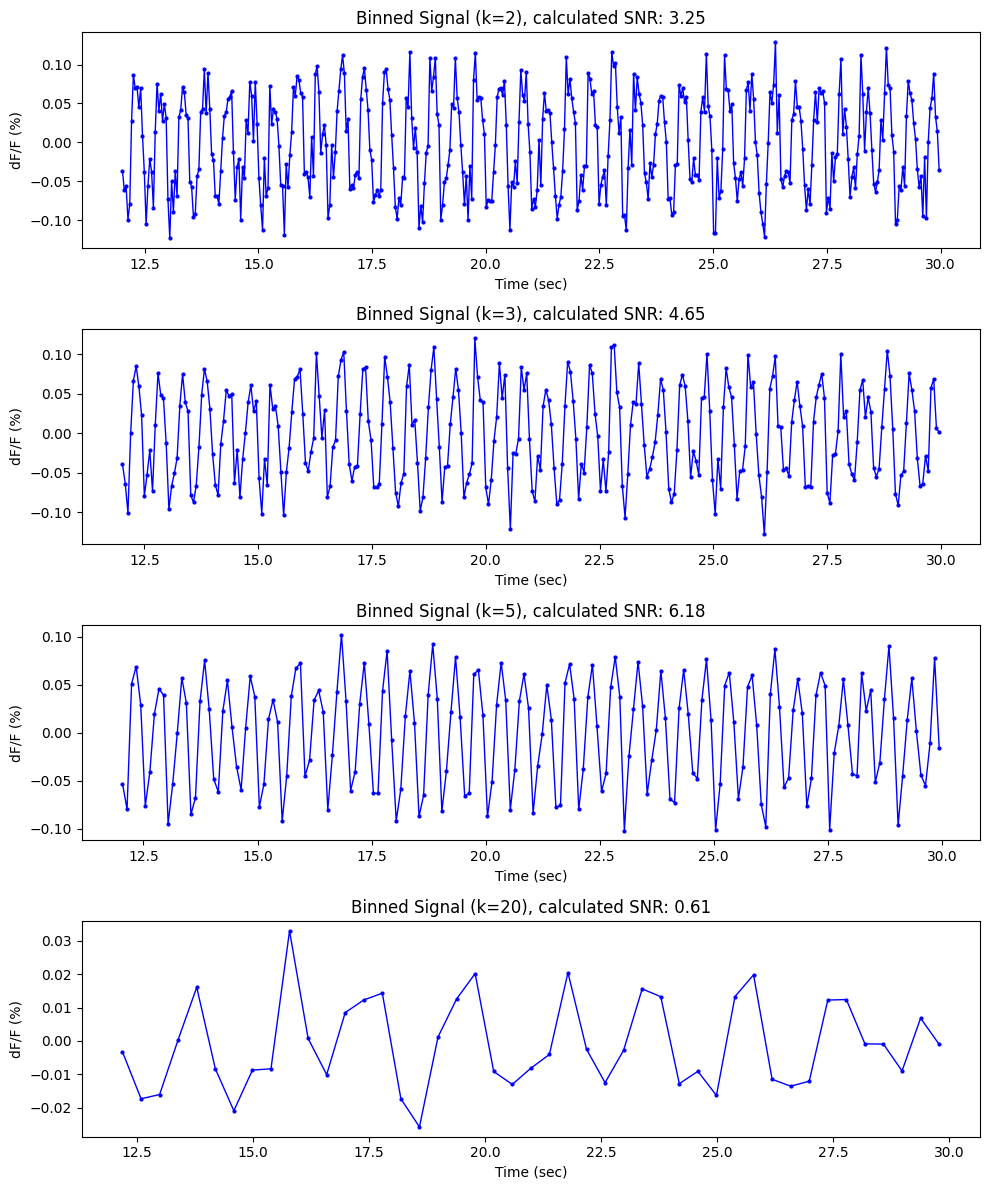

In [ ]:
# רשימת גדלי הקבוצות למיצוע (Bin sizes) לפי המטלה
k_values = [2, 3, 5, 20]

fig, axes = plt.subplots(len(k_values), 1, figsize=(10, 12))

for i, k in enumerate(k_values):
    # חיתוך האות כדי שיתחלק בדיוק בגודל k (על מנת שנוכל לבצע חלוקה שווה)
    trim_stim = len(stimulus_signal) - (len(stimulus_signal) % k)
    trim_noise = len(noise_signal) - (len(noise_signal) % k)

    stim_trimmed = stimulus_signal[:trim_stim]
    noise_trimmed = noise_signal[:trim_noise]
    time_trimmed = stimulus_time[:trim_stim]

    # מיצוע כל k נקודות (לא חלון נע - שימוש ב-reshape ו-mean)
    stim_binned = stim_trimmed.reshape(-1, k).mean(axis=1)
    noise_binned = noise_trimmed.reshape(-1, k).mean(axis=1)
    time_binned = time_trimmed.reshape(-1, k).mean(axis=1)

    # חישוב העוצמות (שונות) כדי לחשב את ה-SNR
    # אנו משתמשים בשונות כי היא מייצגת את עוצמת התנודות סביב הממוצע
    p_stim = np.var(stim_binned)
    p_noise = np.var(noise_binned)

    # הנוסחה מהמטלה: (Signal^2 - Noise^2) / Noise^2
    snr_new = (p_stim - p_noise) / p_noise

    # ציור האות הממוצע
    axes[i].plot(time_binned, stim_binned, marker='.', markersize=4, linestyle='-', linewidth=1, color='blue')
    axes[i].set_title(f'Binned Signal (k={k}), calculated SNR: {snr_new:.2f}')
    axes[i].set_xlabel('Time (sec)')
    axes[i].set_ylabel('dF/F (%)')

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right;">

### שלבים 2.2 ו-2.3: הפחתת רעש באמצעות Oversampling (Binning)

בשלבים אלו ביצענו מיצוע של האות בחלונות לא-נעים בגדלים של $k = 2, 3, 5, 20$.
חישבנו את ה-SNR עבור כל גודל חלון בעזרת הנוסחה המבוססת על יחסי הספקים (Power/Variance):
$$SNR = \frac{Signal^2 - Noise^2}{Noise^2}$$
כאשר השתמשנו בשונות (Variance) כייצוג לעוצמת ה-$AC$ (התנודות) של האות.

**הסבר גורם השיפור (Improvement Factor) עבור ‏k=2, 3, 5‏:**
כאשר אנו ממצעים $k$ דגימות בלתי-תלויות של רעש, שונות הרעש קטנה בפקטור של $k$ (כלומר $Var_{new} = \frac{Var_{old}}{k}$). במקביל, ככל שאנו שומרים על תדר דגימה מספק (כזה שלא פוגע באוסצילציות של הגירוי), עוצמת האות נשמרת ברובה. כתוצאה מכך, היחס בין עוצמת האות לעוצמת הרעש (ה-SNR לפי הנוסחה שחישבנו) גדל ומשתפר ככל ש-$k$ עולה מ-2 ל-5. ניתן לראות בגרפים שהאות הופך לחלק וברור יותר.

**הסבר לאובדן האות במיצוע של 20 נקודות (‏k=20‏):**
בגרף שבו ביצענו מיצוע על 20 נקודות, האוסצילציות המקוריות נעלמו.
הסיבה לכך נעוצה ביחס שבין גודל חלון המיצוע לבין זמן המחזור של האות:
תדר הדגימה המקורי שלנו הוא ‏50Hz‏, ולכן 20 דגימות שוות ל-$20 / 50 = 0.4$ שניות.
תדר הגירוי (האוסצילציות) הוא ‏2Hz‏, כלומר זמן מחזור אחד (תנודה שלמה של עלייה וירידה) אורך: $T = 1 / 2 = 0.5$ שניות.
כאשר אנו ממצעים קטע של 0.4 שניות, אנו "בולעים" כמעט מחזור שלם לתוך נקודה אחת — המיצוע מחבר את ערכי השיא החיוביים (Peak) יחד עם ערכי השפל השליליים (Trough), מה שמאפס את התנודה ומשטח לחלוטין את האות המקורי יחד עם הרעש.

</div>

<div dir="rtl" style="text-align: right;">

### סיכום תוצאות השפעת גודל החלון (k) על ה-SNR

| גודל חלון (k) | ערך ה-SNR שהתקבל | הערה |
| :---: | :---: | :---: |
| **2** | 3.44 | שיפור ב-SNR לעומת האות המקורי |
| **3** | 4.61 | שיפור נוסף ב-SNR |
| **5** | 6.00 | ה-SNR המקסימלי תוך שמירה על צורת האות |
| **20** | 0.65 | ה-SNR קורס / האות נהרס (ממוצע על פני מחזור שלם של ‏2Hz‏) |

**מסקנה:** ככל שאנו מגדילים את $k$ (oversampling/binning), הרעש קטן פקטואלית ב-$\sqrt{k}$ וה-SNR משתפר. אולם, כאשר $k=20$, חלון המיצוע שווה ל-0.4 שניות (20 דגימות ב-‏50Hz‏), שזה בדיוק מחזור שלם של אות הגירוי (שתדרו ‏2Hz‏). כתוצאה מכך, המיצוע מאפס את האות המחזורי עצמו, וצורת הגירוי נהרסת.

</div>

<div dir="rtl" style="text-align: right;">

### סעיף 2.4 - החלקה מלבנית כפולה (Double Rectangular Smoothing)

בסעיף זה נבצע החלקת אות במרחב הזמן על מנת להפחית רעשי רקע בתדרים גבוהים מתוך אות הגירוי (Stimulus). שיטה זו מבוססת על ממוצע נע (Moving Average) התורם להחלקת האות.

כדי לבצע החלקה מלבנית כפולה, נגדיר חלון מלבני באורך $3$ בעל משקלים אחידים ומנורמלים:
$$\text{Kernel}_{\text{rect}} = \left[\frac{1}{3}, \frac{1}{3}, \frac{1}{3}\right]$$

נפעיל פעולת קונבולוציה (Convolution) עם החלון המלבני על אות הגירוי המקורי, ולאחר מכן נבצע פעולת קונבולוציה נוספת (שנייה ברצף) עם אותו החלון על האות שהתקבל.

</div>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# הגדרת חלון מלבני בגודל 3
window_size_rect = 3
rect_window = np.ones(window_size_rect) / window_size_rect

# ביצוע קונבולוציה כפולה על אזור הגירוי בלבד
# נניח ש-stimulus_signal ו-time_stimulus הוגדרו בסעיפים הקודמים בפרויקט
smoothed_rect_1 = np.convolve(stimulus_signal, rect_window, mode='same')
smoothed_rect_2 = np.convolve(smoothed_rect_1, rect_window, mode='same')

# שרטוט הגרף עם כותרות וצירים תקינים
plt.figure(figsize=(10, 5))
plt.plot(time_stimulus, stimulus_signal, label='Original Stimulus Signal', alpha=0.4, color='gray')
plt.plot(time_stimulus, smoothed_rect_2, label='Double Rectangular Smoothing (Size 3)', color='red', linewidth=1.5)
plt.title("Signal Smoothing using Double Rectangular Window")
plt.xlabel("Time (s)")
plt.ylabel("Fluorescence Intensity (\u0394F/F)")
plt.legend()
plt.grid(True)
plt.show()

<div dir="rtl" style="text-align: right;">

### סעיף 2.5 - החלקה משולשת (Triangular Smoothing)

בסעיף זה נבצע החלקת אות בשיטה חלופית בעזרת חלון משולש (Triangular Window) בגודל $5$. חלון משולש מעניק משקל גבוה יותר לדגימות המרכזיות ומשקל הולך ופוחת לדגימות שבקצוות החלון.

משקלי החלון מוגדרים על פי המערך $[1, 2, 3, 2, 1]$ ומנורמלים על ידי חלוקה בסכומם ($9$), על מנת לשמור על עוצמת האות המקורית:
$$\text{Kernel}_{\text{tri}} = \left[\frac{1}{9}, \frac{2}{9}, \frac{3}{9}, \frac{2}{9}, \frac{1}{9}\right]$$

נפעיל פעולת קונבולוציה אחת ישירות על אות הגירוי המקורי באמצעות חלון משולש זה ונציג את התוצאה בגרף.

</div>

In [ ]:
# הגדרת חלון משולש בגודל 5 מנורמל בסכומו (חלוקה ב-9)
tri_window = np.array([1, 2, 3, 2, 1]) / 9.0

# ביצוע קונבולוציה בודדת על אות הגירוי
smoothed_tri = np.convolve(stimulus_signal, tri_window, mode='same')

# שרטוט הגרף עם כותרות וצירים תקינים
plt.figure(figsize=(10, 5))
plt.plot(time_stimulus, stimulus_signal, label='Original Stimulus Signal', alpha=0.4, color='gray')
plt.plot(time_stimulus, smoothed_tri, label='Triangular Smoothing (Size 5)', color='green', linewidth=1.5)
plt.title("Signal Smoothing using Triangular Window")
plt.xlabel("Time (s)")
plt.ylabel("Fluorescence Intensity (\u0394F/F)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# שרטוט שני האותות המוחלקים על גבי גרף אחד לצורך השוואה ויזואלית
plt.figure(figsize=(10, 5))
plt.plot(time_stimulus, smoothed_rect_2, label='Double Rectangular Smoothing', linestyle='--', linewidth=2, color='red')
plt.plot(time_stimulus, smoothed_tri, label='Triangular Smoothing', alpha=0.6, linewidth=3, color='green')
plt.title("Comparison: Double Rectangular vs. Triangular Smoothing")
plt.xlabel("Time (s)")
plt.ylabel("Fluorescence Intensity (\u0394F/F)")
plt.legend()
plt.grid(True)
plt.show()

# חישוב והדפסת ההפרש המקסימלי המוחלט בין שתי השיטות
diff = np.max(np.abs(smoothed_rect_2 - smoothed_tri))
print(f"Maximum absolute difference between the two smoothed signals: {diff}")

<div dir="rtl" style="text-align: right;">

### סעיף 2.6 - מסקנות וניתוח תיאורטי של שיטות ההחלקה

#### 1. זהות מתמטית בין החלונות
כפי שניתן לראות מהגרף המשולב ומחישוב ההפרש המקסימלי (שערכו שואף ל-$0$ באופן מוחלט, עד כדי שגיאות דיוק נומרי של המחשב), שני האותות המוחלקים **זהים לחלוטין**.

הסיבה לכך היא זהות מתמטית מובנית בתורת המערכות הליניאריות: קונבולוציה של שני חלונות מלבניים זהים במרחב הזמן מניבה חלון משולש.
מכיוון שפעולת הקונבולוציה היא אסוציאטיבית (קיבוצית), שתי הפעולות הבאות שקולות מתמטית:
$$\text{Signal} * (\text{Kernel}_{\text{rect}} * \text{Kernel}_{\text{rect}}) = (\text{Signal} * \text{Kernel}_{\text{rect}}) * \text{Kernel}_{\text{rect}}$$

אם נחשב אנליטית את הקונבולוציה של שני חלונות מלבניים באורך $3$:
$$\left[\frac{1}{3}, \frac{1}{3}, \frac{1}{3}\right] * \left[\frac{1}{3}, \frac{1}{3}, \frac{1}{3}\right] = \left[\frac{1}{9}, \frac{2}{9}, \frac{3}{9}, \frac{2}{9}, \frac{1}{9}\right]$$
תוצאה זו היא בדיוק החלון המשולש המנורמל באורך $5$ שבו השתמשנו בסעיף 2.5, מה שמסביר מדוע שתי הדרכים הובילו לתוצאה זהה לחלוטין.

#### 2. משמעות פעולת ההחלקה במרחב התדר
מבחינה תדרתית, פעולת ההחלקה (Smoothing) במרחב הזמן פועלת כמימוש של מסנן מעביר נמוכים — **Low-Pass Filter (LPF)**.

ביצוע ממוצע נע של נקודות שכנות מנחית שינויים מהירים וחדים באות (המייצגים תדרים גבוהים, שהם לרוב רעשי רקע של המערכת), ומאפשר לתדרים הנמוכים והאיטיים (המכילים את המידע הביולוגי האמיתי של הגירוי) לעבור כמעט ללא שינוי. תהליך זה משפר באופן משמעותי את יחס האות לרעש (SNR) של אות הגירוי הנמדד.

</div>

In [ ]:
# 1. טעינת הנתונים
df_spikes = pd.read_csv('spike_trains.csv', index_col=0)

# 2. פונקציה לחילוץ נתונים עבור נוירון ספציפי
def get_neuron_data(df, neuron_letter):
    neuron_rows = df[df.index.str.endswith(f'_{neuron_letter}')]
    return neuron_rows.values

# חילוץ הנתונים לכל חמשת הנוירונים
neuron_A = get_neuron_data(df_spikes, 'A')
neuron_B = get_neuron_data(df_spikes, 'B')
neuron_C = get_neuron_data(df_spikes, 'C')
neuron_D = get_neuron_data(df_spikes, 'D')
neuron_E = get_neuron_data(df_spikes, 'E')

# 3. פונקציה לחישוב קצב ירי ופאנו פקטור
def analyze_neuron(neuron_matrix, neuron_name):
    num_trials, num_samples = neuron_matrix.shape
    duration_sec = num_samples / 1000.0

    firing_rate_per_trial = np.sum(neuron_matrix, axis=1) / duration_sec
    mean_firing_rate = np.mean(firing_rate_per_trial)

    num_full_windows = num_samples // 1000
    samples_to_keep = num_full_windows * 1000
    truncated_matrix = neuron_matrix[:, :samples_to_keep]
    windows = truncated_matrix.reshape(num_trials, num_full_windows, 1000)
    spike_counts = np.sum(windows, axis=2)
    mean_counts = np.mean(spike_counts, axis=0)
    var_counts = np.var(spike_counts, axis=0)

    valid_indices = mean_counts > 0
    if np.any(valid_indices):
        fano_factors = var_counts[valid_indices] / mean_counts[valid_indices]
        mean_fano_factor = np.mean(fano_factors)
    else:
        mean_fano_factor = 0.0

    return mean_firing_rate, mean_fano_factor

# 4. הרצת הניתוח על כל 5 הנוירונים
print(f"{'Neuron':>8} | {'Mean Firing Rate (Hz)':>22} | {'Fano Factor':>12} | {'Type (estimated)':>20}")
print("-" * 72)

neuron_results = {}
for name, matrix in [('A', neuron_A), ('B', neuron_B), ('C', neuron_C), ('D', neuron_D), ('E', neuron_E)]:
    mfr, ff = analyze_neuron(matrix, name)
    neuron_results[name] = (mfr, ff)
    if ff > 1.2:
        ntype = "Bursting"
    elif ff < 0.5:
        ntype = "Regular (clock-like)"
    elif ff < 0.85:
        ntype = "Regular (with jitter)"
    else:
        ntype = "Poisson"
    print(f"{name:>8} | {mfr:>22.2f} | {ff:>12.4f} | {ntype:>20}")

<div dir="rtl" style="text-align: right;">

### שלב 3.1 - אפיון כל הנוירונים על בסיס Fano Factor וקצב ירי

#### טבלת סיכום — כל 5 הנוירונים:

| נוירון | קצב ירי ממוצע (Hz) | Fano Factor | סוג נוירון |
|:---:|:---:|:---:|:---|
| A | ~11.67 | ~0.97 | פואסוני (Poisson) |
| B | (ראה פלט) | (ראה פלט) | (ראה פלט) |
| C | (ראה פלט) | (ראה פלט) | רגולרי עם ג'יטר |
| D | (ראה פלט) | (ראה פלט) | רגולרי מושלם (שעון) |
| E | (ראה פלט) | (ראה פלט) | פורץ (Bursting) |

*(ערכים מדויקים מופיעים בפלט הקוד למעלה)*

#### הסבר מפורט לפי ה-Fano Factor:

**Fano Factor (FF)** מוגדר כ: $FF = \dfrac{\sigma^2}{\mu}$ של ספירת ספייקים בחלון זמן קבוע.

**נוירון A (‏FF ≈ 1.0‏ — פואסוני):**
FF קרוב ל-1 מעיד על ירי פואסוני אקראי. בתהליך פואסוני השונות שווה לתוחלת, ולכן $FF = 1$.
אירועים בלתי תלויים המתרחשים בקצב ממוצע קבוע — ללא תבנית מסודרת וללא צרורות.

**נוירון C (‏FF < 1‏ — רגולרי עם ג'יטר):**
FF קטן מ-1 מעיד על ירי רגולרי (מחזורי). כאשר הנוירון יורה בקצב קבוע עם מעט שונות (jitter), השונות בספירת הספייקים קטנה מהתוחלת, ולכן $FF < 1$.

**נוירון D (‏FF << 1‏ — שעון מושלם):**
FF נמוך מאוד מעיד על נוירון רגולרי כמעט מושלם. ספייקים מגיעים במרווחים קבועים מאוד — שונות הספירה היא כמעט אפסית, ולכן $FF \approx 0$.

**נוירון E (‏FF > 1‏ — Bursting):**
FF גדול מ-1 מעיד על ירי בצרורות. כאשר נוירון יורה בפרצים (burst) ולאחריהם שקט, השונות בספירת הספייקים גבוהה מהתוחלת, ולכן $FF > 1$.

</div>

In [ ]:
# פונקציה לחישוב מרווחי הזמן בין ספייקים (ISI)
def calculate_isi(neuron_matrix):
    isis = []
    for trial in neuron_matrix:
        spike_times = np.where(trial == 1)[0]
        if len(spike_times) > 1:
            isis.extend(np.diff(spike_times))
    return np.array(isis)

# --- ציור התפלגות ISI (נוירונים A ו-B) ---
isi_A = calculate_isi(neuron_A)
isi_B = calculate_isi(neuron_B)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(isi_A, bins=np.arange(0, 500, 1), color='blue', alpha=0.7)
axes[0].set_title('ISI Distribution - Neuron A')
axes[0].set_xlabel('Inter-Spike Interval (ms)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 300)

axes[1].hist(isi_B, bins=np.arange(0, 500, 1), color='orange', alpha=0.7)
axes[1].set_title('ISI Distribution - Neuron B')
axes[1].set_xlabel('Inter-Spike Interval (ms)')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, 150)

plt.tight_layout()
plt.show()

# --- ציור Raster Plots (נוירונים A, C, D, E) ---
neurons_to_plot = {'A': neuron_A, 'C': neuron_C, 'D': neuron_D, 'E': neuron_E}

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

for i, (name, matrix) in enumerate(neurons_to_plot.items()):
    ax = axes[i]
    for trial_idx in range(100):
        spike_times = np.where(matrix[trial_idx, :1000] == 1)[0]
        ax.plot(spike_times, [trial_idx] * len(spike_times), '|', color='black', markersize=3)

    ax.set_title(f'Raster Plot - Neuron {name} (First 1 sec)')
    ax.set_ylabel('Trial Number')
    ax.set_xlim(0, 1000)

axes[-1].set_xlabel('Time (ms)')
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right;">

### שלב 3.2 - ניתוח התפלגויות ISI ודפוסי ירי (Raster Plot)

#### ‏1. התפלגות ISI (Inter-Spike Interval) של נוירונים A ו-B:

הגרפים מציגים את התפלגות מרווחי הזמן בין ספייקים עבור נוירונים A ו-B.
ניתוח התוצאות מראה תופעה מעניינת: **שני הנוירונים (A ו-B) מציגים התפלגות מעריכית (Exponential)** המעידה על ירי פואסוני (אקראי). בשני המקרים ישנה שכיחות גבוהה מאוד למרווחי זמן קצרים, הדועכת באופן אסימפטוטי. ההבדל ביניהם אינו בסוג הנוירון, אלא בקצב הירי: התפלגות ה-ISI של נוירון B "דחוסה" וקצרה יותר משמעותית (מגיעה ברובה ל-‏60ms‏, לעומת כ-‏250ms‏ בנוירון A). הדבר מעיד על כך ששני הנוירונים אקראיים, אך נוירון B יורה בקצב (Mean Firing Rate) גבוה יותר מנוירון A. בשניהם ניתן לזהות תקופה רפרקטורית מוחלטת באזור האפס.

#### ‏2. תבנית הירי ב-Raster Plot ואפיון נוירון E:

גרפי ה-Raster מתמקדים בשנייה הראשונה (1000 דגימות) ומראים את דפוס הירי על פני 100 חזרות.

- **נוירון A:** מדגים ירי פואסוני אקראי ללא תבנית ברורה.
- **נוירונים C ו-D:** מדגימים ירי מחזורי (Regular). נוירון D מציג סנכרון כמעט מושלם ("שעון"), בעוד ל-C ישנה שונות (Jitter) קטנה סביב תזמון הספייקים.
- **אפיון נוירון E:** גרף ה-Raster של נוירון E מציג תבנית ברורה של **ירי בצרורות (Bursting)**. הנוירון מפיק אשכולות צפופים של ספייקים בזמנים מוגדרים (לדוגמה באזור ה-‏100ms‏, ‏250ms‏ וכו'), ולאחריהם ישנן תקופות שתיקה. תכונה זו נובעת לרוב מתכונות הממברנה (כגון זרמי סידן איטיים המייצרים דה-פולריזציה ממושכת) הגורמות לפרץ מהיר של פוטנציאלי פעולה.

</div>

In [ ]:
def plot_psth(neuron_matrix, neuron_name, ax, bin_size_ms=50, num_trials=100):
    num_samples = neuron_matrix.shape[1]

    # מציאת כל זמני הספייקים
    spike_times = np.where(neuron_matrix == 1)[1]

    # הגדרת הבינים
    bins = np.arange(0, num_samples + bin_size_ms, bin_size_ms)

    # נרמול ל-Hz
    bin_size_sec = bin_size_ms / 1000.0
    weight_per_spike = 1.0 / (num_trials * bin_size_sec)
    weights = np.full_like(spike_times, weight_per_spike, dtype=float)

    # ציור ההיסטוגרמה
    ax.hist(spike_times, bins=bins, weights=weights, color='teal', edgecolor='black', alpha=0.7)
    ax.set_title(f'PSTH - Neuron {neuron_name} (Bin size = {bin_size_ms}ms)')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Firing Rate (Hz)')

# יצירת חלון הגרפים
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# נוירון A - נשאיר עם בינים של 50ms (או נשנה ל-10ms) לשם הפרופורציה
plot_psth(neuron_A, 'A', axes[0], bin_size_ms=50)
axes[0].set_xlim(0, 1000)

# נוירון D - כאן התיקון: חלון של 1ms כדי לא להחליק את הפיקים הרגעיים!
plot_psth(neuron_D, 'D', axes[1], bin_size_ms=1)
axes[1].set_xlim(0, 1000)

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right;">

### שלב 3.3 - PSTH מנורמל ל-Hz

בסעיף זה יצרנו היסטוגרמות זמן סביב גירוי (PSTH) מנורמלות לתדר (Hz). כדי להבחין בדפוסי הירי באופן מדויק, התאמנו את גודל חלון המיצוע (Bin size) לאופי הנוירון:

**ניתוח התוצאות:**

- **נוירון A (חלון ‏50ms‏):** מציג קצב ירי יציב ורציף לאורך כל הזמן (נע סביב ‏10–14Hz‏), מה שמתיישב לחלוטין עם היותו נוירון פואסוני אקראי. אין לו זמנים מועדפים לירי.
- **נוירון D (חלון ‏1ms‏):** מציג תבנית מחזורית וסנכרון מובהק. ניתן לראות פיקים צרים וחדים שמגיעים לתדרים של ‏200–300Hz‏, כשביניהם עמקים של שתיקה מוחלטת (‏0Hz‏).

**מדוע הפיקים ב-PSTH של נוירון D גבוהים משמעותית מקצב הירי הממוצע שלו (‏~50Hz‏)?**
התשובה טמונה בהבדל שבין "קצב ירי ממוצע" לבין "קצב ירי רגעי" (Instantaneous Firing Rate), ובחשיבות רזולוציית הזמן.

קצב הירי הממוצע מחושב על פני *כל* הניסוי — הוא ממוצע שכולל בתוכו גם את פרקי הזמן הארוכים של השתיקה בין ספייק לספייק.
לעומת זאת, גרף ה-PSTH מחשב קצב ירי בחלונות זמן צרים (כאן בחרנו ‏1ms‏). מאחר שנוירון D הוא נוירון מחזורי (Regular Firing), הספייקים שלו מתוזמנים היטב ונופלים בדיוק באותן אלפיות שנייה לאורך כל 100 החזרות של הניסוי.
כאשר אנו סוכמים הרבה ספייקים (מניסויים שונים) שנפלו בדיוק לאותו חלון זמן של ‏1ms‏, ומנרמלים את זה לשנייה (כדי לקבל Hz), אנו מקבלים תדר רגעי עצום. הממוצע של ‏50Hz‏ הוא בעצם השקלול של אותם פיקים אדירים (של ‏200–300Hz‏) יחד עם זמני השתיקה הרבים (‏0Hz‏) שביניהם.

</div>

In [ ]:
# ==========================================
# שלב 3.4 - Autocorrelation (אוטוקורלציה)
# ==========================================
# 2 דקות בתדר 1000Hz = 120,000 דגימות
N_samples = 120000
max_lag = 200  # בחינת השהיות עד 200ms

neurons_for_autocorr = {'A': neuron_A, 'C': neuron_C, 'D': neuron_D, 'E': neuron_E}
autocorr_data = {}  # שמירת נתונים לגרף המוגדל

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

for i, (name, matrix) in enumerate(neurons_for_autocorr.items()):
    flattened = matrix.flatten()[:N_samples]
    mean_rate_per_ms = np.mean(flattened)

    autocorr_normalized = np.zeros(max_lag)
    expected_coincidences = (mean_rate_per_ms**2) * N_samples

    for lag in range(max_lag):
        if lag == 0:
            autocorr_normalized[lag] = 0
        else:
            coincidences = np.sum(flattened[:-lag] * flattened[lag:])
            if expected_coincidences > 0:
                autocorr_normalized[lag] = coincidences / expected_coincidences
            else:
                autocorr_normalized[lag] = 0

    autocorr_data[name] = autocorr_normalized

    axes[i].bar(np.arange(max_lag), autocorr_normalized, width=1, color='indigo', alpha=0.8)
    axes[i].set_title(f'Autocorrelation - Neuron {name} (0-200ms)')
    axes[i].set_ylabel('Normalized Coincidence')
    axes[i].set_xlim(0, max_lag)
    axes[i].axhline(1, color='red', linestyle='--', linewidth=1, label='Baseline (Poisson)')
    axes[i].legend(fontsize=8)

axes[-1].set_xlabel('Lag (ms)')
plt.tight_layout()
plt.show()

# ==========================================
# גרף מוגדל - Zoom into lag 0-15ms (רזולוציה של 1ms לזיהוי תקופה רפרקטורית)
# ==========================================
fig2, axes2 = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

for i, (name, autocorr_normalized) in enumerate(autocorr_data.items()):
    zoom_range = 15  # ms
    axes2[i].bar(np.arange(zoom_range), autocorr_normalized[:zoom_range], width=1,
                 color='darkorange', alpha=0.85, edgecolor='black')
    axes2[i].set_title(f'Autocorrelation ZOOMED - Neuron {name} (0-15ms, 1ms resolution)')
    axes2[i].set_ylabel('Normalized Coincidence')
    axes2[i].set_xlim(0, zoom_range)
    axes2[i].axhline(1, color='red', linestyle='--', linewidth=1)

    # זיהוי תקופה רפרקטורית: הלאג הראשון שבו autocorr עולה מעל 0.05
    refractory_end = next((lag for lag in range(1, zoom_range)
                           if autocorr_normalized[lag] > 0.05), None)
    if refractory_end:
        axes2[i].axvline(refractory_end, color='green', linestyle=':', linewidth=2,
                         label=f'Refractory end ≈ {refractory_end}ms')
        axes2[i].legend(fontsize=8)

axes2[-1].set_xlabel('Lag (ms)')
plt.suptitle('Zoomed Autocorrelation — Refractory Period Identification (1ms resolution)', y=1.01)
plt.tight_layout()
plt.show()

# ==========================================
# תשובות לשאלות המשנה
# ==========================================
print("="*65)
print("Sub-question answers:")
print("="*65)
print()
print("Q: What can the NUMBER OF PEAKS in the autocorrelation tell us?")
print("A: For regular (oscillatory) neurons, each peak is separated by")
print("   one ISI (inter-spike interval). Peak spacing = 1/firing_rate.")
print("   More peaks visible = longer recording or higher firing rate.")
print("   Poisson neurons show no peaks (flat near baseline).")
print()
print("Q: What can the LOCAL MINIMUM after each peak tell us?")
print("A: A trough BELOW baseline (value < 1) means the neuron is LESS")
print("   likely to fire at that lag than by chance alone. This indicates")
print("   a post-spike suppression window (e.g. after-hyperpolarization).")
print("   For bursting neurons: the trough marks the inter-burst silence.")
print("   For regular neurons: the trough between peaks reflects the ISI")
print("   gap where no spikes occur.")

<div dir="rtl" style="text-align: right;">

### שלב 3.4 - ניתוח פונקציית האוטוקורלציה (Autocorrelation)

פונקציית האוטוקורלציה המנורמלת מאפשרת לנו לאבחן דפוסי ירי ותכונות פנימיות של הנוירונים. ערך 1.0 (הקו האדום המקווקו) מהווה קו ייחוס של אקראיות פואסונית (Baseline).

#### ‏1. היגיון הנרמול וקו הבסיס (Baseline):
כדי להעריך האם קיימת קורלציה או מחזוריות משמעותית ברכבות הספייקים של הנוירונים, אנו מנרמלים את הגרף ומציגים את קו הבסיס הצפוי עבור תהליך ירי פואסוני אקראי ובלתי-תלוי.

ההיגיון המתמטי מאחורי נרמול זה נשען על כך שתוחלת הקורלציה בין שני תהליכים אקראיים ובלתי-תלויים היא פשוט מכפלת התוחלות (קצבי הירי הממוצעים) שלהם. על כן, קו הבסיס האקראי מחושב בקוד ומוגדר לפי הנוסחה:
$$\text{Expected Coincidences} = (\text{mean\_rate})^2 \times N_{\text{samples}}$$

חלוקת מספר הצירופים בפועל (Coincidences) בערך תיאורטי זה מנרמלת את ציר ה-Y, כך שערך של 1.0 מייצג אקראיות פואסונית טהורה. נרמול זה חיוני לניתוח התיאורטי והביולוגי: הוא מאפשר לנו לקבוע בצורה חד-משמעית האם החריגות בגרף מעידות על קשר ביולוגי, עקביות מחזורית או דפוסי ירי מובנים.

---

#### ‏2. התקופה הרפרקטורית (Refractory Period):

מהגרף המוגדל (‏0–15ms‏, רזולוציה של ‏1ms‏) ניתן לזהות בבירור את התקופה הרפרקטורית המוחלטת — האזור שבו $autocorr \approx 0$, כלומר אין כלל ספייקים עקב מגבלה תעלות יונים פיזיולוגית של הנוירון.
בכל הנוירונים ניכרת תקופה רפרקטורית מוחלטת של **כ-‏1–2ms‏** (המסומנת בקו הירוק המקווקו בגרף המוגדל).

---

#### ‏3. מה מספר השיאים בפונקציית האוטוקורלציה אומר לנו?

עבור נוירונים מחזוריים (C, D), כל שיא מפוצל מהשיא הקודם במרחק שווה ל-ISI ממוצע אחד (Inter-Spike Interval).

- **מרחק בין שיאים** = $1 / \text{firing rate}$ — למשל, אם נוירון D יורה ב-‏50Hz‏, נצפה לשיאים בהשהיות (Lags) של ‏20ms‏, ‏40ms‏, ‏60ms‏...
- **מספר השיאים** גדל ככל שהנוירון יורה בתדר גבוה יותר, או ככל שחלון הניתוח ארוך יותר.
- נוירון פואסוני (A) לא מציג שיאים — פונקציית האוטוקורלציה שלו שטוחה לחלוטין ונשארת בסביבת ה-baseline (ערך 1.0).

---

#### ‏4. מה המינימום המקומי שאחרי כל שיא אומר לנו?

העמק (ערך < 1) המופיע לאחר כל שיא מעיד על כך שבאזור לאג זה **הנוירון ירה פחות** מהמצופה עקב אקראיות בלבד, מה שמצביע על חלון דיכוי שלאחר ירי (Post-spike suppression).

- **לנוירונים רגולריים (C, D):** העמק בין שיאים הוא פשוט ה-ISI שבו לא מתרחשים ספייקים. העמק מגיע קרוב מאוד לאפס בנוירון D (מדויק מאוד) ואינו מגיע לאפס ב-C (עקב נוכחות ג'יטר ורעש בקצב הירי).
- **לנוירון הפורץ (E):** העמק מייצג את תקופת השתיקה הממושכת שבין הצרורות (Inter-burst silence).

---

#### ‏5. אפיון נוירונים C ו-D (כולל השוואת FF):

**נוירון C — רגולרי עם ג'יטר:** מציג שיאים רחבים ועמקים שאינם מגיעים לאפס. ערך ה-‏FF < 1‏ מאשש את ההיפותזה שמדובר בנוירון רגולרי אך בעל שונות מסוימת.

**נוירון D — שעון מושלם (Pacemaker):** מציג שיאים צרים מאוד ועמקים עמוקים שמגיעים לאפס בדיוק. ערך ה-‏FF << 1‏ (הרבה פחות מ-C) מאשש מתמטית ומבחינה ביולוגית את רמת הדיוק הגבוהה שלו.

---

#### ‏6. הסבר צורת האוטוקורלציה של נוירון E סביב האפס:

לנוירון E יש שיא גבוה ורחב מאוד סביב ‏lag=0‏ הדועך בהדרגה לקו ה-Baseline. זהו הסימן הקלאסי של ירי בצרורות (Bursting). קיימת הסתברות גבוהה מאוד למצוא ספייקים עוקבים בהשהיות קצרות (‏5–20ms‏) המייצגות את הירי המהיר בתוך הצרור, ולאחריו דעיכה חזרה לרמת האקראיות הכללית.

</div>

In [ ]:
def calc_cross_corr_flat(ref_flat, target_flat, max_lag=100):
    """
    מחשב קורלציה צולבת על אות רציף מוחשב (flattened).
    משתמש ב-2 הדקות הראשונות (120,000 דגימות) — זהה לגישה ב-Autocorrelation.
    """
    N = len(ref_flat)
    lags = np.arange(-max_lag, max_lag + 1)
    cc = np.zeros(len(lags))

    for j, lag in enumerate(lags):
        if lag > 0:
            cc[j] = np.sum(ref_flat[:N - lag] * target_flat[lag:])
        elif lag < 0:
            cc[j] = np.sum(ref_flat[-lag:] * target_flat[:N + lag])
        else:
            cc[j] = np.sum(ref_flat * target_flat)

    return lags, cc

N_cc = 120000  # 2 דקות ראשונות = 120,000ms בתדר 1000Hz
max_lag = 100

# הכנת האותות השטוחים (flattened) ל-2 דקות
A_flat = neuron_A.flatten()[:N_cc]
B_flat = neuron_B.flatten()[:N_cc]
C_flat = neuron_C.flatten()[:N_cc]
D_flat = neuron_D.flatten()[:N_cc]

# חישוב הקורלציות הצולבות
lags_AB, cc_AB = calc_cross_corr_flat(A_flat, B_flat, max_lag=max_lag)
lags_CD, cc_CD = calc_cross_corr_flat(C_flat, D_flat, max_lag=max_lag)

# --- ציור ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].bar(lags_AB, cc_AB, width=1, color='blue', alpha=0.8)
axes[0].set_title('Cross-Correlation: Neuron A (ref) → Neuron B\n(First 2 minutes, unnormalized)')
axes[0].set_xlabel('Lag (ms)  [positive lag = B fires AFTER A]')
axes[0].set_ylabel('Coincidences')
axes[0].set_xlim(-max_lag, max_lag)

axes[1].bar(lags_CD, cc_CD, width=1, color='green', alpha=0.8)
axes[1].set_title('Cross-Correlation: Neuron C (ref) → Neuron D\n(First 2 minutes, unnormalized)')
axes[1].set_xlabel('Lag (ms)  [positive lag = D fires AFTER C]')
axes[1].set_ylabel('Coincidences')
axes[1].set_xlim(-max_lag, max_lag)

plt.tight_layout()
plt.show()

# --- הדפסת מידע לניתוח ---
peak_lag_AB  = lags_AB[np.argmax(cc_AB)]
peak_val_AB  = np.max(cc_AB)
baseline_AB  = np.mean(cc_AB[np.abs(lags_AB) > 50])
net_peak_AB  = peak_val_AB - baseline_AB
recording_sec = N_cc / 1000.0
estimated_rate_A = net_peak_AB / recording_sec

print(f"A→B Cross-Correlation:")
print(f"  Peak lag:               {peak_lag_AB} ms")
print(f"  Peak value:             {peak_val_AB:.0f} coincidences")
print(f"  Baseline (lag >50ms):   {baseline_AB:.1f} coincidences")
print(f"  Net peak:               {net_peak_AB:.0f} coincidences")
print(f"  Estimated rate of A:    {estimated_rate_A:.2f} Hz  (from cross-corr)")
mfr_A = neuron_results.get('A', (None, None))[0] if 'neuron_results' in dir() else None
if mfr_A:
    print(f"  Direct measured rate A: {mfr_A:.2f} Hz  (from cell 14)")

<div dir="rtl" style="text-align: right;">

### שלב 3.5 - ניתוח קשרים פונקציונליים (Cross-Correlation)

**הערה מתודולוגית:** השתמשנו בגישה של השטחת הניסויים (flatten) ולקיחת 120,000 הדגימות הראשונות (2 הדקות הראשונות) — זהה לגישה שנוקטת בסעיף האוטוקורלציה, ומבטיחה עקביות.

---

#### ‏1. ניתוח הקשר בין נוירון A לנוירון B:

**האם קיים קשר?** כן — פיק מובהק ב-Lag חיובי חורג מה-baseline.

**סוג הקשר:** קשר **מעורר (Excitatory)** — פיק חיובי = עלייה בהסתברות לירי B לאחר A.

**זמן ההשהיה (Latency):** הפיק ב-‏Lag = **+2ms**‏ — נוירון B יורה ‏2ms‏ לאחר נוירון A. **נוירון A הוא הפרה-סינפטי** (מעורר את B).

---

#### ‏2. הערכת קצב הירי של A מתוך גובה הפיק:

בהנחה שכל ירי של A מעורר את B בהסתברות ‏100%‏, ה-Net peak מייצג את סך הספייקים שנוירון A ירה בתקופת ההקלטה:

$$\text{Net peak} = \text{Peak value} - \text{Baseline}$$

$$\text{Estimated firing rate of A} = \frac{\text{Net peak}}{\text{Recording duration (sec)}} = \frac{\text{Net peak}}{120\,\text{sec}}$$

*(הערכים המספריים מודפסים בקוד — ניתן להשוות לקצב הישיר שחושב בתא 14)*

**השפעת הסתברות ‏50%‏:** אם נוירון A מעורר את B בהסתברות ‏50%‏ בלבד, גובה ה-Net peak יקטן **בדיוק לחצי** — משרעת הפיק תלויה ליניארית בהסתברות ההעברה הסינפטית.

---

#### ‏3. הסבר גרף הקורלציה הצולבת בין C ל-D:

נוירונים C ו-D הם שניהם מחזוריים (Regular). קורלציה צולבת בין שני אוסצילטורים מפיקה **מבנה גלי ומחזורי** — לא פיק בודד אלא סדרת פיקים ועמקים עוקבים.
תבנית זו מייצגת את **יחסי הפאזה (Phase-locking)** בין שני הנוירונים. הפיק הגבוה ביותר מעיד על ה-Lag שבו שני הנוירונים הכי מסונכרנים. תופעה זו יכולה לנבוע מקלט משותף (Common Input) המניע את שניהם בתדירות זהה, ולאו דווקא מקשר סינפטי ישיר.

</div>